# 🧠 Red Neuronal Artificial: Perceptrón Multicapa (MLP)

En este notebook se entrena y evalúa la arquitectura propuesta del Perceptrón Multicapa (MLP) utilizando Keras/TensorFlow para la predicción de riesgo de accidente cerebrovascular.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")

print("Scikit-Learn cargado correctamente")

### 1. Carga de Datos Preprocesados

In [1]:
import numpy as np

data = np.load('../data/processed/model_ready_data.npz')

X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7776, 15)
X_test shape: (1022, 15)


### 2. Definición del Modelo MLP

Definimos la arquitectura propuesta:
- Capa Oculta 1: 64 neuronas, ReLU, BatchNormalization, Dropout(0.3)
- Capa Oculta 2: 32 neuronas, ReLU, BatchNormalization, Dropout(0.3)
- Capa de Salida: 1 neurona, Sigmoid

Iteration 1, loss = 0.59922578
Iteration 2, loss = 0.46591094
Iteration 3, loss = 0.42376619
Iteration 4, loss = 0.40658285
Iteration 5, loss = 0.39521634
Iteration 6, loss = 0.38608213
Iteration 7, loss = 0.37736560
Iteration 8, loss = 0.36964452
Iteration 9, loss = 0.36295703
Iteration 10, loss = 0.35603740
Iteration 11, loss = 0.34951987
Iteration 12, loss = 0.34405797
Iteration 13, loss = 0.33840231
Iteration 14, loss = 0.33227918
Iteration 15, loss = 0.32781550
Iteration 16, loss = 0.32245420
Iteration 17, loss = 0.31846314
Iteration 18, loss = 0.31473663
Iteration 19, loss = 0.31002201
Iteration 20, loss = 0.30507747
Iteration 21, loss = 0.30132760
Iteration 22, loss = 0.29895862
Iteration 23, loss = 0.29475622
Iteration 24, loss = 0.29105113
Iteration 25, loss = 0.28646429
Iteration 26, loss = 0.28432245
Iteration 27, loss = 0.28202285
Iteration 28, loss = 0.27679155
Iteration 29, loss = 0.27571692
Iteration 30, loss = 0.27114903
Iteration 31, loss = 0.26876543
Iteration 32, los

c:\Users\ZAP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


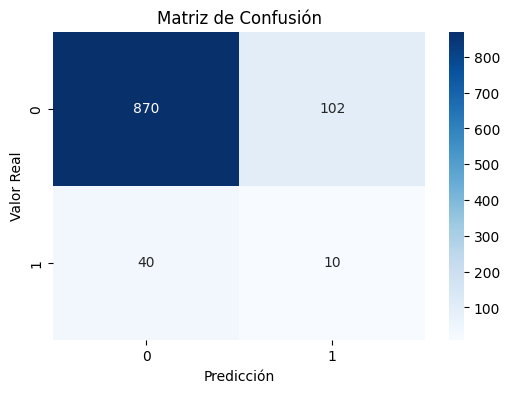

In [4]:
# ==========================================
# RED NEURONAL MULTICAPA (MLP)
# ==========================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Crear modelo
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Dos capas ocultas
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    verbose=True
)

# Entrenamiento
model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

# ==========================================
# PREDICCIONES
# ==========================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ==========================================
# MÉTRICAS
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("\n===== RESULTADOS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_score:.4f}")

print("\n===== REPORTE DE CLASIFICACIÓN =====")
print(classification_report(y_test, y_pred))

# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

### 3. Entrenamiento con MLPClassifier

In [5]:
# ==========================================
# ENTRENAMIENTO DEL MODELO
# ==========================================

from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,      # Equivalente aproximado a EarlyStopping
    validation_fraction=0.2,  # 20% para validación
    n_iter_no_change=12,      # Paciencia
    random_state=42,
    verbose=True
)

history = model.fit(X_train, y_train)

print("Entrenamiento finalizado")

Iteration 1, loss = 0.62397111
Validation score: 0.775064
Iteration 2, loss = 0.49361915
Validation score: 0.793702
Iteration 3, loss = 0.44294070
Validation score: 0.812339
Iteration 4, loss = 0.42215725
Validation score: 0.831620
Iteration 5, loss = 0.41009540
Validation score: 0.838689
Iteration 6, loss = 0.40151530
Validation score: 0.842545
Iteration 7, loss = 0.39352479
Validation score: 0.843188
Iteration 8, loss = 0.38707001
Validation score: 0.843830
Iteration 9, loss = 0.37938246
Validation score: 0.846401
Iteration 10, loss = 0.37356543
Validation score: 0.848329
Iteration 11, loss = 0.36742002
Validation score: 0.845758
Iteration 12, loss = 0.36264295
Validation score: 0.849614
Iteration 13, loss = 0.35925602
Validation score: 0.855398
Iteration 14, loss = 0.35171122
Validation score: 0.858612
Iteration 15, loss = 0.34795805
Validation score: 0.858612
Iteration 16, loss = 0.34330782
Validation score: 0.865039
Iteration 17, loss = 0.33820549
Validation score: 0.866324
Iterat

### 4. Evaluación de Curvas de Entrenamiento

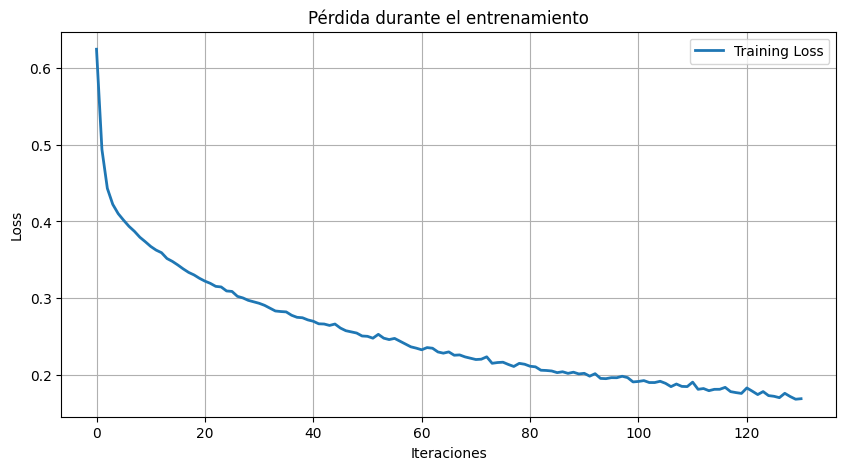

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# CURVA DE PÉRDIDA DEL ENTRENAMIENTO
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    model.loss_curve_,
    linewidth=2,
    label='Training Loss'
)

plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### 5. Predicción y Reporte de Clasificación

In [8]:
# Predicciones continuas en Test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("--- Reporte de Clasificación (MLP) ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación (MLP) ---
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       972
           1       0.12      0.36      0.18        50

    accuracy                           0.83      1022
   macro avg       0.54      0.61      0.54      1022
weighted avg       0.92      0.83      0.87      1022



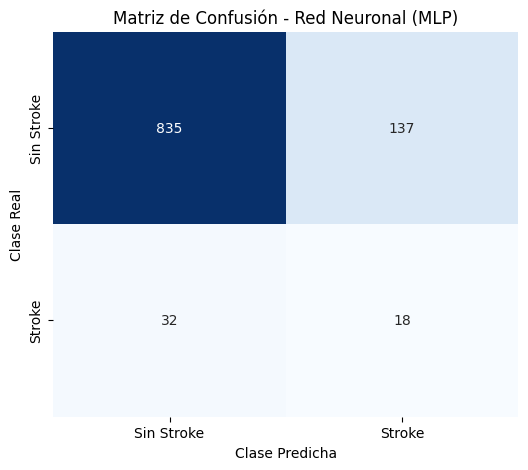

In [9]:
# Graficar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sin Stroke', 'Stroke'],
            yticklabels=['Sin Stroke', 'Stroke'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Red Neuronal (MLP)')
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Verificar que existan las variables necesarias
if 'y_pred_prob' not in locals():
    raise ValueError("La variable 'y_pred_prob' no está definida. Debes generar las probabilidades con el modelo.")

# Crear predicciones binarias si no existen
if 'y_pred' not in locals():
    y_pred = (y_pred_prob >= 0.5).astype(int)

# Si predict devuelve una matriz (n,1), convertirla a vector
y_pred_prob = np.ravel(y_pred_prob)
y_test = np.ravel(y_test)

# Graficar Curva ROC y calcular AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=2,
         label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Red Neuronal MLP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Crear carpeta si no existe
os.makedirs('../data/processed', exist_ok=True)

# Guardar predicciones
np.savez(
    '../data/processed/mlp_predictions.npz',
    y_pred_prob=y_pred_prob,
    y_pred=y_pred
)

print("Predicciones guardadas correctamente en:")
print("../data/processed/mlp_predictions.npz")

NameError: name 'roc_curve' is not defined